In [28]:
!nvidia-smi


Tue Jun 23 14:28:53 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   76C    P0             33W /   70W |    1111MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [29]:
!pip install ultralytics roboflow -q

In [30]:
from ultralytics import YOLO
from roboflow import Roboflow

In [32]:
# @title
rf = Roboflow(api_key="") # API key is hidden

project = rf.workspace("augmented-startups").project("football-player-detection-kucab")

dataset = project.version(7).download("yolo26")

loading Roboflow workspace...
loading Roboflow project...
Exporting format yolo26 in progress : 95.0%
Version export complete for yolo26 format


In [33]:
!cat /content/Football-Player-Detection-7/data.yaml

names:
- football
- player
nc: 2
roboflow:
  license: CC BY 4.0
  project: football-player-detection-kucab
  url: https://universe.roboflow.com/augmented-startups/football-player-detection-kucab/dataset/7
  version: 7
  workspace: augmented-startups
test: ../test/images
train: ../train/images
val: ../valid/images


In [35]:
model = YOLO("yolo26n.pt")

In [36]:
results = model.train(
    data="/content/Football-Player-Detection-7/data.yaml",
    epochs=10,
    imgsz=640,
    batch=16,
    device=0
)

Ultralytics 8.4.75 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/Football-Player-Detection-7/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train-2, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=Tru

In [37]:
!ls /content/runs/detect/train/weights

best.pt  last.pt


In [38]:
!/content/runs/detect/train/weights/best.pt

/bin/bash: line 1: /content/runs/detect/train/weights/best.pt: Permission denied


In [39]:
metrics = model.val()

print(metrics)

Ultralytics 8.4.75 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO26n summary (fused): 122 layers, 2,375,226 parameters, 0 gradients, 5.2 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2978.3±781.2 MB/s, size: 132.8 KB)
val: Scanning /content/Football-Player-Detection-7/valid/labels.cache... 243 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 243/243 84.9Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 16/16 2.0it/s 8.0s
                   all        243       4513      0.836       0.64      0.683      0.433
              football        199        262      0.779      0.347      0.399      0.203
                player        242       4251      0.893      0.932      0.967      0.663
Speed: 3.5ms preprocess, 6.2ms inference, 0.0ms loss, 0.4ms postprocess per image
Results saved to /content/runs/detect/val-2
ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index:

In [40]:
model = YOLO("/content/runs/detect/train/weights/best.pt")

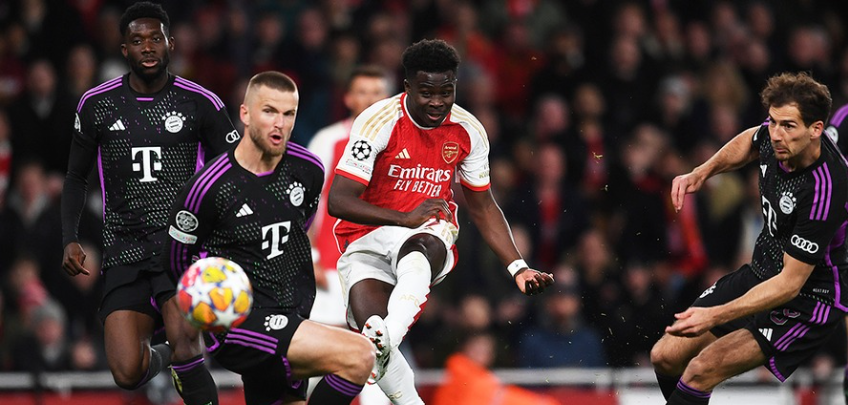

In [51]:
from IPython.display import Image

Image("/content/Test.jpg")

In [52]:
results = model.predict(
    source="/content/Test.jpg",
    conf=0.25,
    save=True
)


image 1/1 /content/Test.jpg: 320x640 1 player, 13.1ms
Speed: 2.7ms preprocess, 13.1ms inference, 1.9ms postprocess per image at shape (1, 3, 320, 640)
Results saved to /content/runs/detect/predict-2


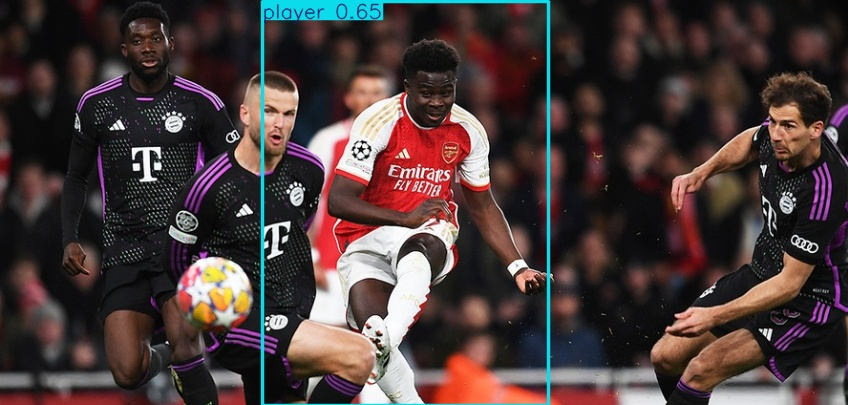

In [53]:
from IPython.display import Image

Image("/content/runs/detect/predict-2/Test.jpg")

In [54]:
results = model.predict(
    source="/content/Test_2.jpg",
    conf=0.25,
    save=True
)


image 1/1 /content/Test_2.jpg: 448x640 3 players, 8.5ms
Speed: 2.1ms preprocess, 8.5ms inference, 1.4ms postprocess per image at shape (1, 3, 448, 640)
Results saved to /content/runs/detect/predict-2


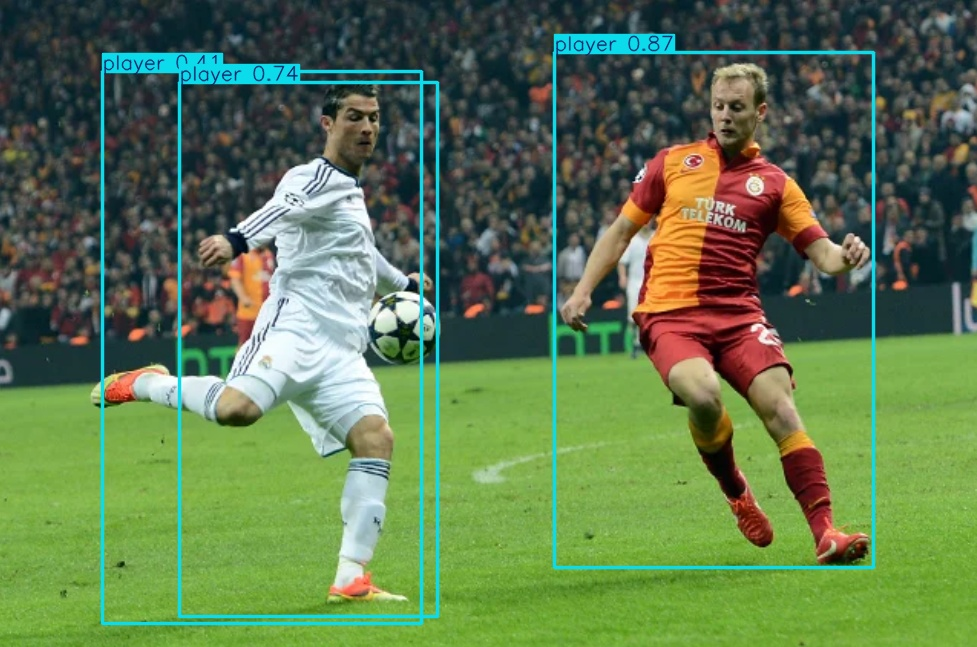

In [55]:
from IPython.display import Image

Image("/content/runs/detect/predict-2/Test_2.jpg")

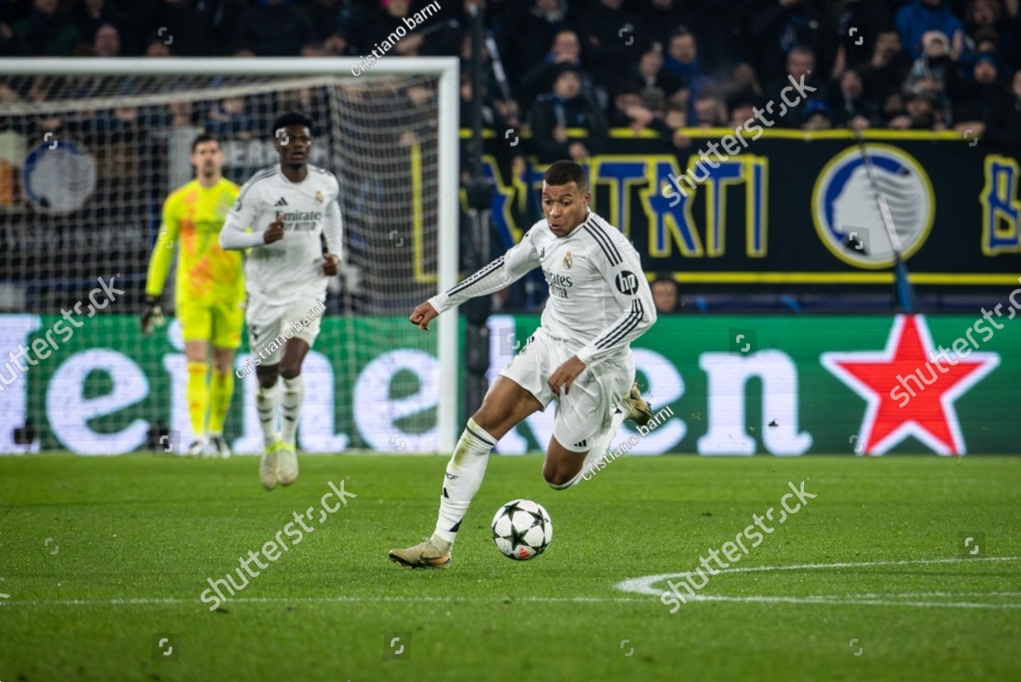

In [56]:
from IPython.display import Image

Image("/content/Test_3.jpg")

In [57]:
results = model.predict(
    source="/content/Test_3.jpg",
    conf=0.25,
    save=True
)


image 1/1 /content/Test_3.jpg: 448x640 1 football, 5 players, 9.0ms
Speed: 3.8ms preprocess, 9.0ms inference, 1.7ms postprocess per image at shape (1, 3, 448, 640)
Results saved to /content/runs/detect/predict-2


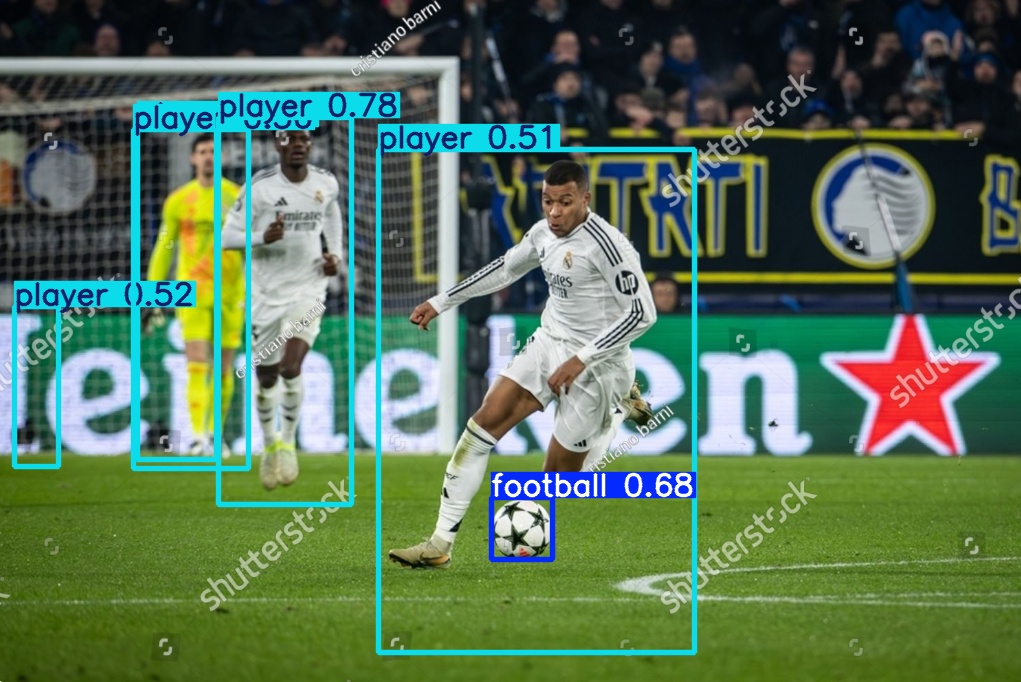

In [58]:
from IPython.display import Image

Image("/content/runs/detect/predict-2/Test_3.jpg")